# 🧠 CT/MRI Registration Pipeline — Clean Version
> **SimpleITK only | No ANTs | Fast & Reliable**

| Cell | Stage | Description | Est. Time |
|------|-------|-------------|-----------|
| 1 | Install | Dependencies | once/session |
| 2 | Config | Set file paths | < 5 sec |
| 3 | SynthSeg | Brain prediction (optional) | 2–5 min |
| 4 | Helpers | Load functions | < 5 sec |
| 5 | Preprocess | Load → Resample → Normalize → Center align | < 30 sec |
| 6 | Rigid | 6-DOF registration | ~1 min |
| 7 | Affine | 12-DOF refinement | ~1 min |
| 8 | Deformable | Demons non-linear warp | ~1 min |
| 9 | Validation | Visual + Dice score | < 30 sec |

**Total: ~4–5 minutes** ✅  
**Run in order top → bottom. Never skip a cell.**

## ⚙️ Cell 1 — Install Dependencies
Run once per session.

In [1]:
!pip install SimpleITK nibabel matplotlib numpy vtk -q

import torch
print("✅ GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("   GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️  No GPU — Runtime → Change runtime type → T4 GPU")

✅ GPU available: False
⚠️  No GPU — Runtime → Change runtime type → T4 GPU


## 📁 Cell 2 — User Config
Edit the three paths below to match your files. Everything else is automatic.

In [3]:
import os

# ── USER EDIT: set your file paths here ──────────────────────────────────────
CT_PATH    = '/Users/lapastang/Documents/head-Model-label.nii.gz'    # fixed image  (CT / THUMS voxel mask)
MRI_PATH   = '/Users/lapastang/Documents/Segmentation-Segment_1-label.nii.gz'    # moving image (MRI / brain volume)
OUTPUT_DIR = 'outputs/case01'                 # all outputs saved here
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✅ Output folder: {OUTPUT_DIR}")
print(f"   CT path  : {CT_PATH}   exists={os.path.exists(CT_PATH)}")
print(f"   MRI path : {MRI_PATH}  exists={os.path.exists(MRI_PATH)}")

✅ Output folder: outputs/case01
   CT path  : /Users/lapastang/Documents/head-Model-label.nii.gz   exists=True
   MRI path : /Users/lapastang/Documents/Segmentation-Segment_1-label.nii.gz  exists=True


## 🧠 Cell 3 — Brain Prediction (SynthSeg) — Optional
Runs SynthSeg skull-stripping before registration.  
Set `RUN_SYNTHSEG = False` to skip and use raw MRI directly.

In [4]:
import os, subprocess
import SimpleITK as sitk

RUN_SYNTHSEG = True   # ← set False to skip

SYNTHSEG_OUT     = os.path.join(OUTPUT_DIR, 'mri_brain_predicted.nii.gz')
SYNTHSEG_SEG_OUT = os.path.join(OUTPUT_DIR, 'mri_brain_segmentation.nii.gz')
BRAIN_PATH       = MRI_PATH   # default: use raw MRI if SynthSeg unavailable

if RUN_SYNTHSEG:
    # Option A: SynthSeg Python package
    try:
        from SynthSeg.predict import predict
        print("✅ SynthSeg Python package found — running predict()...")
        predict(
            path_images     = MRI_PATH,
            path_segm       = SYNTHSEG_SEG_OUT,
            path_posteriors = None,
            path_resampled  = SYNTHSEG_OUT,
            fast            = True,
            robust          = False,
        )
        BRAIN_PATH = SYNTHSEG_OUT
        print(f"✅ Brain prediction saved to: {SYNTHSEG_OUT}")

    except ImportError:
        # Option B: FreeSurfer mri_synthseg CLI
        try:
            print("⚠️  SynthSeg package not found. Trying mri_synthseg CLI...")
            result = subprocess.run(
                ['mri_synthseg', '--i', MRI_PATH, '--o', SYNTHSEG_SEG_OUT,
                 '--resample', SYNTHSEG_OUT, '--fast'],
                capture_output=True, text=True
            )
            if result.returncode == 0:
                BRAIN_PATH = SYNTHSEG_OUT
                print(f"✅ mri_synthseg complete. Brain saved to: {SYNTHSEG_OUT}")
            else:
                print("❌ mri_synthseg failed — falling back to raw MRI.")
                print(result.stderr[-300:])
        except FileNotFoundError:
            print("❌ mri_synthseg not found — falling back to raw MRI.")

    if BRAIN_PATH != MRI_PATH and os.path.exists(BRAIN_PATH):
        brain_img = sitk.ReadImage(BRAIN_PATH)
        print(f"   Brain size   : {brain_img.GetSize()}")
        print(f"   Brain spacing: {[round(s,2) for s in brain_img.GetSpacing()]}")
    else:
        BRAIN_PATH = MRI_PATH
        print("⚠️  Using original MRI_PATH (no skull stripping applied).")
else:
    print("⏭️  RUN_SYNTHSEG=False — skipping.")

print(f"\n📌 BRAIN_PATH = {BRAIN_PATH}")

⚠️  SynthSeg package not found. Trying mri_synthseg CLI...
❌ mri_synthseg not found — falling back to raw MRI.
⚠️  Using original MRI_PATH (no skull stripping applied).

📌 BRAIN_PATH = /Users/lapastang/Documents/Segmentation-Segment_1-label.nii.gz


## 🔧 Cell 4 — Imports & Helper Functions
All shared functions live here. Run once, use everywhere below.

In [6]:
import os
import numpy as np
import SimpleITK as sitk
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# ── Helper: Fix zero/invalid spacing ─────────────────────────────────────────
def fix_spacing(img, default_spacing=1.0):
    #"""Replace any near-zero spacing values with default_spacing."""    
    spacing = list(img.GetSpacing())
    corrected = [s if s > 0.001 else default_spacing for s in spacing]
    if corrected != spacing:
        print(f"⚠️  Corrected spacing: {spacing} → {corrected}")
        img.SetSpacing(corrected)
    return img


# ── Helper: Isotropic Resampling ─────────────────────────────────────────────
def resample_isotropic(image, voxel_size=1.0, interpolator=sitk.sitkLinear):
    #"""Resample image to isotropic voxel spacing (default 1 mm)."""    
    orig_spacing = image.GetSpacing()
    orig_size    = image.GetSize()
    new_size     = [
        int(round(orig_size[i] * (orig_spacing[i] / voxel_size)))
        for i in range(3)
    ]
    return sitk.Resample(
        image, new_size, sitk.Transform(),
        interpolator, image.GetOrigin(),
        [voxel_size] * 3, image.GetDirection(),
        0.0, image.GetPixelID()
    )


# ── Helper: Min-Max Intensity Normalization ───────────────────────────────────
def normalize_intensity(image):
    #"""Scale pixel values to [0, 1]. Fast replacement for N4 bias correction."""    
    arr  = sitk.GetArrayFromImage(image).astype(np.float32)
    vmin, vmax = arr.min(), arr.max()
    if vmax - vmin < 1e-6:
        return image   # avoid division by zero on blank images
    out = sitk.GetImageFromArray((arr - vmin) / (vmax - vmin))
    out.CopyInformation(image)
    return out


# ── Helper: Affine diagnosis from nibabel ────────────────────────────────────
def print_affine_info(path):
    #"""Print nibabel affine and zooms for a NIfTI file — useful for debugging origin mismatches."""    
    img = nib.load(path)
    print(f"Affine:\n{img.affine}")
    print(f"Zooms: {img.header.get_zooms()}")


# ── Helper: Print image properties ───────────────────────────────────────────
def print_image_info(name, img):
    #"""Print key spatial properties of a SimpleITK image."""    
    print(f"{name}:")
    print(f"  Size    : {img.GetSize()}")
    print(f"  Spacing : {[round(s,3) for s in img.GetSpacing()]}")
    print(f"  Origin  : {[round(o,2) for o in img.GetOrigin()]}")
    arr = sitk.GetArrayFromImage(img)
    nz  = int(np.count_nonzero(arr))
    tot = int(arr.size)
    print(f"  Min/Max : {arr.min():.4f} / {arr.max():.4f}")
    print(f"  Nonzero : {nz:,} / {tot:,} ({100*nz/tot:.1f}%)")


# ── Helper: Overlay Visualisation ────────────────────────────────────────────
def show_overlay(fixed, moving_reg, title="Registration Result", slices=None):
    #"""3-plane overlay: CT (fixed) in red, registered MRI in green.Yellow = overlap. Saves PNG to OUTPUT_DIR."""
    def norm(a):
        a = a.astype(np.float32)
        mn, mx = a.min(), a.max()
        return (a - mn) / (mx - mn + 1e-8)

    f_arr = norm(sitk.GetArrayFromImage(fixed))
    m_arr = norm(sitk.GetArrayFromImage(moving_reg))

    z_mid = f_arr.shape[0] // 2
    y_mid = f_arr.shape[1] // 2
    x_mid = f_arr.shape[2] // 2
    if slices is None:
        slices = [z_mid, y_mid, x_mid]

    views = [
        (f_arr[slices[0], :, :], m_arr[slices[0], :, :], "Axial"),
        (f_arr[:, slices[1], :], m_arr[:, slices[1], :], "Coronal"),
        (f_arr[:, :, slices[2]], m_arr[:, :, slices[2]], "Sagittal"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for ax, (ct_sl, mri_sl, label) in zip(axes, views):
        rgb = np.zeros((*ct_sl.shape, 3), dtype=np.float32)
        rgb[..., 0] = ct_sl    # red   = CT
        rgb[..., 1] = mri_sl   # green = MRI  →  yellow where both overlap
        ax.imshow(rgb, origin='lower')
        ax.set_title(f"{label}  |  🔴 CT  🟢 MRI  🟡 Overlap")
        ax.axis('off')
    plt.tight_layout()
    out = os.path.join(OUTPUT_DIR, f"{title.replace(' ', '_')}.png")
    plt.savefig(out, dpi=120)
    plt.show()
    print(f"✅ Saved overlay to: {out}")


# ── Helper: Metric convergence callback ──────────────────────────────────────
metric_log = []
def log_metric(method):
    #"""Callback: appends (iteration, metric_value) to metric_log every 20 iters."""    
    v = method.GetMetricValue()
    i = method.GetOptimizerIteration()
    metric_log.append((i, v))
    if i % 20 == 0:
        print(f"   Iter {i:04d}  |  Metric: {v:.6f}")


# ── Helper: Plot metric convergence ──────────────────────────────────────────
def plot_convergence(title="Convergence", color='steelblue'):
    #"""Plot metric_log after a registration stage completes."""    
    if not metric_log:
        print("No metric log to plot.")
        return
    iters, vals = zip(*metric_log)
    plt.figure(figsize=(8, 3))
    plt.plot(iters, vals, color=color)
    plt.xlabel('Iteration')
    plt.ylabel('MI Metric')
    plt.title(f'{title} (more negative = better)')
    plt.tight_layout()
    plt.show()


# ── Helper: Checkerboard view ─────────────────────────────────────────────────
def checkerboard(a, b, block=20):
    #"""Alternate patches from images a and b for visual alignment check."""    
    out = np.zeros_like(a)
    for i in range(0, a.shape[0], block):
        for j in range(0, a.shape[1], block):
            if ((i // block) + (j // block)) % 2 == 0:
                out[i:i+block, j:j+block] = a[i:i+block, j:j+block]
            else:
                out[i:i+block, j:j+block] = b[i:i+block, j:j+block]
    return out


print("✅ All helper functions loaded.")

✅ All helper functions loaded.


## 🔬 Cell 5 — Preprocess: Load → Resample → Normalize → Center Align
Stages 1 & 2. Produces `fixed`, `moving`, and `initial_tx` used by all downstream cells.

📂 Loading images...
CT  (raw):
  Size    : (309, 249, 202)
  Spacing : [1.926, 1.926, 1.926]
  Origin  : [256.0, 4.12, 38.3]
  Min/Max : 0.0000 / 1.0000
  Nonzero : 7,313,333 / 15,542,082 (47.1%)

MRI (raw):
  Size    : (240, 512, 512)
  Spacing : [1.0, 1.0, 1.0]
  Origin  : [0.0, 0.0, 0.0]
  Min/Max : 0.0000 / 1.0000
  Nonzero : 3,728,860 / 62,914,560 (5.9%)

🔄 Stage 1a: Resampling to 1.0 mm isotropic...
   CT  → (595, 480, 389)
   MRI → (240, 512, 512)

🔄 Stage 1b: Normalizing intensity to [0, 1]...
   Done.

🎯 Stage 2: Geometric Center Alignment...


/var/folders/km/p4qb_jt537j4wmhh3n7wzb1m0000gn/T/ipykernel_76240/84464288.py:102: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/km/p4qb_jt537j4wmhh3n7wzb1m0000gn/T/ipykernel_76240/84464288.py:102: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/km/p4qb_jt537j4wmhh3n7wzb1m0000gn/T/ipykernel_76240/84464288.py:102: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/km/p4qb_jt537j4wmhh3n7wzb1m0000gn/T/ipykernel_76240/84464288.py:104: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(out, dpi=120)
/var/folders/km/p4qb_jt537j4wmhh3n7wzb1m0000gn/T/ipykernel_76240/84464288.py:104: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(out, dpi=120)
/var/folders/km/p4qb_jt537j4wmhh3n7wzb1m0000gn/T/

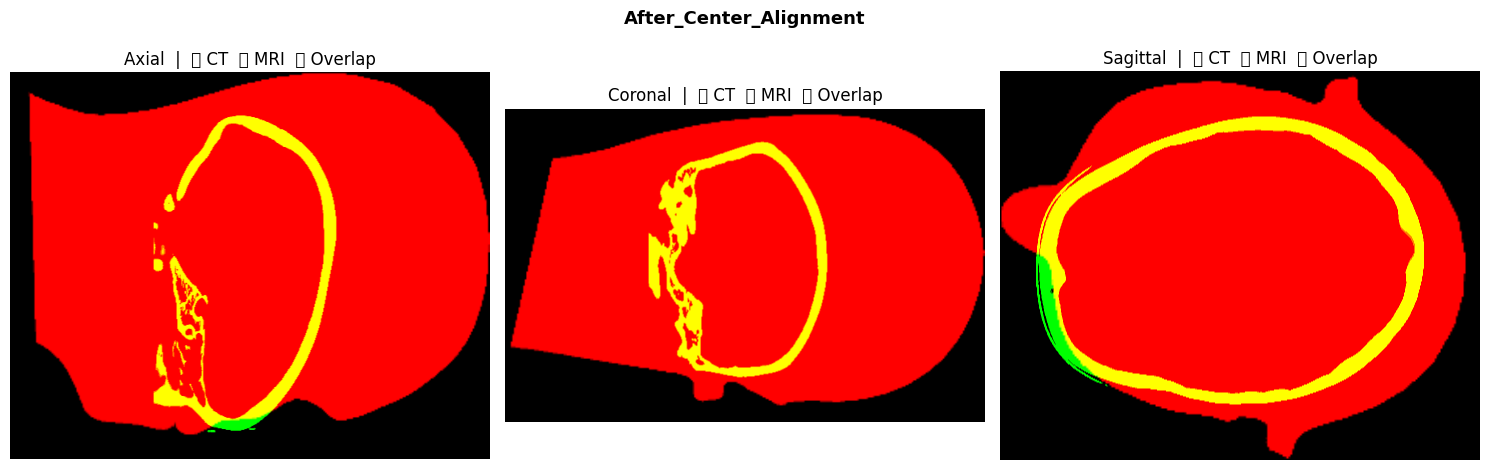

✅ Saved overlay to: outputs/case01/After_Center_Alignment.png
✅ Stage 1 & 2 complete.


In [7]:
print("📂 Loading images...")
fixed_raw  = sitk.ReadImage(CT_PATH,    sitk.sitkFloat32)
moving_raw = sitk.ReadImage(BRAIN_PATH, sitk.sitkFloat32)
print_image_info("CT  (raw)", fixed_raw)
print()
print_image_info("MRI (raw)", moving_raw)

# ── Stage 1a: Fix any bad spacing values ─────────────────────────────────────
fixed_raw  = fix_spacing(fixed_raw)
moving_raw = fix_spacing(moving_raw)

# ── Stage 1b: Resample to 1 mm isotropic ────────────────────────────────────
print("\n🔄 Stage 1a: Resampling to 1.0 mm isotropic...")
fixed  = resample_isotropic(fixed_raw,  voxel_size=1.0)
moving = resample_isotropic(moving_raw, voxel_size=1.0)
print(f"   CT  → {fixed.GetSize()}")
print(f"   MRI → {moving.GetSize()}")

# ── Stage 1c: Min-max intensity normalisation ─────────────────────────────────
print("\n🔄 Stage 1b: Normalizing intensity to [0, 1]...")
fixed  = normalize_intensity(fixed)
moving = normalize_intensity(moving)
print("   Done.")

# Save preprocessed volumes
sitk.WriteImage(fixed,  os.path.join(OUTPUT_DIR, 'ct_preprocessed.nii.gz'))
sitk.WriteImage(moving, os.path.join(OUTPUT_DIR, 'mri_preprocessed.nii.gz'))

# ── Stage 2: Geometric center alignment ──────────────────────────────────────
print("\n🎯 Stage 2: Geometric Center Alignment...")
initial_tx = sitk.CenteredTransformInitializer(
    fixed, moving,
    sitk.Euler3DTransform(),
    sitk.CenteredTransformInitializerFilter.GEOMETRY   # align by bounding-box centre
)

# Preview center alignment
resampler = sitk.ResampleImageFilter()
resampler.SetReferenceImage(fixed)
resampler.SetInterpolator(sitk.sitkLinear)
resampler.SetDefaultPixelValue(0)
resampler.SetTransform(initial_tx)
moving_centered = resampler.Execute(moving)

show_overlay(fixed, moving_centered, title="After_Center_Alignment")
print("✅ Stage 1 & 2 complete.")

## 🦴 Cell 6 — Stage 3: Rigid Registration
6-DOF (rotation + translation). Initialised from the center-aligned transform.

🦴 Stage 3: Rigid Registration...
   Iter 0000  |  Metric: -0.065858
   Iter 0000  |  Metric: -0.064131
   Iter 0000  |  Metric: -0.047465

   Metric : -0.046282
   Stop   : GradientDescentOptimizerv4Template: Convergence checker passed at iteration 9.


/var/folders/km/p4qb_jt537j4wmhh3n7wzb1m0000gn/T/ipykernel_76240/84464288.py:102: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/km/p4qb_jt537j4wmhh3n7wzb1m0000gn/T/ipykernel_76240/84464288.py:102: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/km/p4qb_jt537j4wmhh3n7wzb1m0000gn/T/ipykernel_76240/84464288.py:102: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/km/p4qb_jt537j4wmhh3n7wzb1m0000gn/T/ipykernel_76240/84464288.py:104: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(out, dpi=120)
/var/folders/km/p4qb_jt537j4wmhh3n7wzb1m0000gn/T/ipykernel_76240/84464288.py:104: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(out, dpi=120)
/var/folders/km/p4qb_jt537j4wmhh3n7wzb1m0000gn/T/

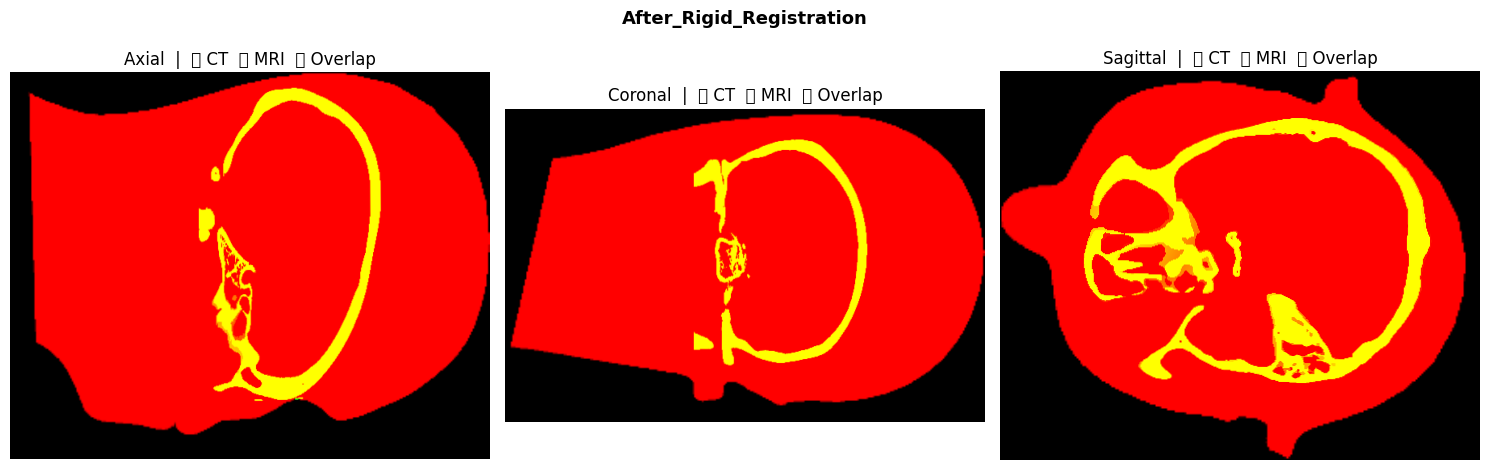

✅ Saved overlay to: outputs/case01/After_Rigid_Registration.png


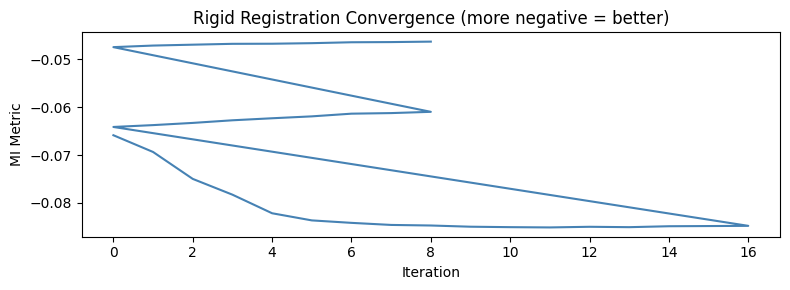

✅ Stage 3 (Rigid) complete.


In [8]:
print("🦴 Stage 3: Rigid Registration...")
metric_log.clear()

reg_rigid = sitk.ImageRegistrationMethod()

# Metric: Mattes Mutual Information (50 bins, 15% random sampling)
reg_rigid.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)
reg_rigid.SetMetricSamplingStrategy(reg_rigid.RANDOM)
reg_rigid.SetMetricSamplingPercentage(0.15)

reg_rigid.SetInterpolator(sitk.sitkLinear)

# Multi-resolution pyramid: coarse → fine
reg_rigid.SetShrinkFactorsPerLevel([4, 2, 1])
reg_rigid.SetSmoothingSigmasPerLevel([2, 1, 0])
reg_rigid.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

# Gradient descent optimiser
reg_rigid.SetOptimizerAsGradientDescent(
    learningRate            = 1.0,
    numberOfIterations      = 200,
    convergenceMinimumValue = 1e-6,
    convergenceWindowSize   = 10
)
reg_rigid.SetOptimizerScalesFromPhysicalShift()

# Initialise from geometric center (Stage 2 result)
reg_rigid.SetInitialTransform(initial_tx, inPlace=False)
reg_rigid.AddCommand(sitk.sitkIterationEvent, lambda: log_metric(reg_rigid))

rigid_tx = reg_rigid.Execute(fixed, moving)
print(f"\n   Metric : {reg_rigid.GetMetricValue():.6f}")
print(f"   Stop   : {reg_rigid.GetOptimizerStopConditionDescription()}")

# Apply rigid transform
resampler.SetTransform(rigid_tx)
moving_rigid = resampler.Execute(moving)
sitk.WriteImage(moving_rigid, os.path.join(OUTPUT_DIR, 'mri_rigid.nii.gz'))

show_overlay(fixed, moving_rigid, title="After_Rigid_Registration")
plot_convergence("Rigid Registration Convergence", color='steelblue')
print("✅ Stage 3 (Rigid) complete.")

## 🔧 Cell 7 — Stage 4: Affine Refinement
12-DOF (adds scaling & shearing). Initialised directly from the rigid result — not from identity.

🔧 Stage 4: Affine Refinement...
   Iter 0000  |  Metric: -0.059568
   Iter 0000  |  Metric: -0.046226
   Iter 0020  |  Metric: -0.047528
   Iter 0040  |  Metric: -0.050864
   Iter 0060  |  Metric: -0.056360
   Iter 0080  |  Metric: -0.062204
   Iter 0100  |  Metric: -0.063225

   Metric : -0.062963
   Stop   : GradientDescentOptimizerv4Template: Convergence checker passed at iteration 116.


/var/folders/km/p4qb_jt537j4wmhh3n7wzb1m0000gn/T/ipykernel_76240/84464288.py:102: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/km/p4qb_jt537j4wmhh3n7wzb1m0000gn/T/ipykernel_76240/84464288.py:102: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/km/p4qb_jt537j4wmhh3n7wzb1m0000gn/T/ipykernel_76240/84464288.py:102: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/km/p4qb_jt537j4wmhh3n7wzb1m0000gn/T/ipykernel_76240/84464288.py:104: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(out, dpi=120)
/var/folders/km/p4qb_jt537j4wmhh3n7wzb1m0000gn/T/ipykernel_76240/84464288.py:104: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(out, dpi=120)
/var/folders/km/p4qb_jt537j4wmhh3n7wzb1m0000gn/T/

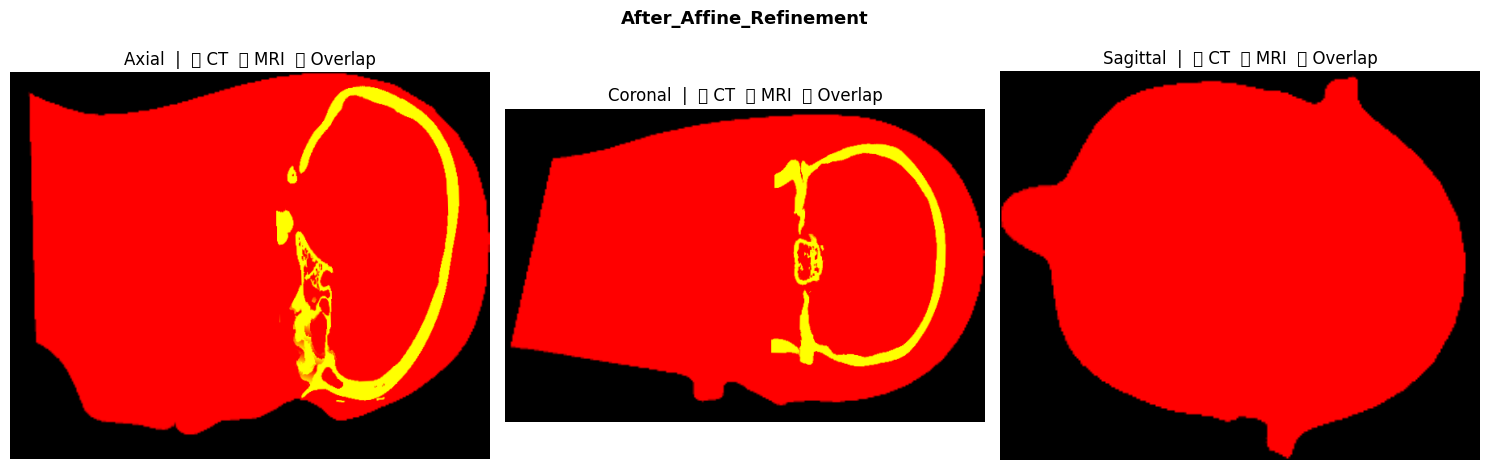

✅ Saved overlay to: outputs/case01/After_Affine_Refinement.png


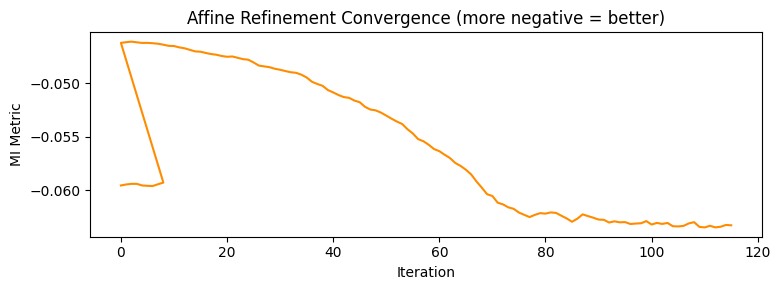

✅ Stage 4 (Affine) complete.


In [9]:
print("🔧 Stage 4: Affine Refinement...")
metric_log.clear()

reg_affine = sitk.ImageRegistrationMethod()

reg_affine.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)
reg_affine.SetMetricSamplingStrategy(reg_affine.RANDOM)
reg_affine.SetMetricSamplingPercentage(0.15)
reg_affine.SetInterpolator(sitk.sitkLinear)

# Finer pyramid — rigid already handled the coarse level
reg_affine.SetShrinkFactorsPerLevel([2, 1])
reg_affine.SetSmoothingSigmasPerLevel([1, 0])
reg_affine.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

reg_affine.SetOptimizerAsGradientDescent(
    learningRate            = 0.5,
    numberOfIterations      = 150,
    convergenceMinimumValue = 1e-6,
    convergenceWindowSize   = 10
)
reg_affine.SetOptimizerScalesFromPhysicalShift()

# KEY: initialise from rigid result — not from identity
reg_affine.SetInitialTransform(rigid_tx, inPlace=False)
reg_affine.AddCommand(sitk.sitkIterationEvent, lambda: log_metric(reg_affine))

affine_tx     = reg_affine.Execute(fixed, moving)
print(f"\n   Metric : {reg_affine.GetMetricValue():.6f}")
print(f"   Stop   : {reg_affine.GetOptimizerStopConditionDescription()}")

# Apply affine transform
resampler.SetTransform(affine_tx)
moving_affine = resampler.Execute(moving)
sitk.WriteImage(moving_affine, os.path.join(OUTPUT_DIR, 'mri_affine.nii.gz'))
sitk.WriteImage(fixed,         os.path.join(OUTPUT_DIR, 'ct_resampled.nii.gz'))

show_overlay(fixed, moving_affine, title="After_Affine_Refinement")
plot_convergence("Affine Refinement Convergence", color='darkorange')
print("✅ Stage 4 (Affine) complete.")

In [ ]:
#fix differences in origin and spacing pixel
RUN_DEFORMABLE = True

if RUN_DEFORMABLE:
    print("🌀 Deformable Registration (Demons)...")

    # ── Ensure both images are identical grid before Demons ──────────────────
    # Demons requires pixel-perfect same size/spacing/origin — resample moving
    # onto fixed grid explicitly first
    moving_on_fixed = sitk.Resample(
        moving_affine, fixed,
        sitk.Transform(),        # identity — just regrid
        sitk.sitkLinear, 0.0, moving_affine.GetPixelID()
    )

    # Cast both to Float32 (Demons requires this)
    fixed_f32  = sitk.Cast(fixed,          sitk.sitkFloat32)
    moving_f32 = sitk.Cast(moving_on_fixed, sitk.sitkFloat32)

    # Verify sizes match before running
    print(f"   Fixed  size : {fixed_f32.GetSize()}")
    print(f"   Moving size : {moving_f32.GetSize()}")
    assert fixed_f32.GetSize() == moving_f32.GetSize(), \
        f"Size mismatch: {fixed_f32.GetSize()} vs {moving_f32.GetSize()}"

    demons = sitk.DemonsRegistrationFilter()
    demons.SetNumberOfIterations(50)
    demons.SetStandardDeviations(1.5)

    disp_field = demons.Execute(fixed_f32, moving_f32)

    # Verify field is non-empty before saving
    field_size = disp_field.GetSize()
    print(f"   Displacement field size: {field_size}")
    assert all(s > 0 for s in field_size), \
        f"Empty displacement field {field_size} — Demons failed silently"

    # Apply displacement field
    disp_tx       = sitk.DisplacementFieldTransform(disp_field)
    moving_deform = sitk.Resample(
        moving, fixed, disp_tx,
        sitk.sitkLinear, 0.0, moving.GetPixelID()
    )

    sitk.WriteImage(moving_deform,
                    os.path.join(OUTPUT_DIR, 'thums_deformable_final.nii.gz'))

    # Cast field to VectorFloat32 before saving (required by ITK writer)
    disp_field_cast = sitk.Cast(disp_field, sitk.sitkVectorFloat32)
    sitk.WriteImage(disp_field_cast,
                    os.path.join(OUTPUT_DIR, 'displacement_field.nii.gz'))

    show_overlay(fixed, moving_deform, title="After_Deformable_FINAL")
    FINAL_MOVING = moving_deform
    print("✅ Deformable done")
    print("📌 FINAL_MOVING = moving_deform")

else:
    FINAL_MOVING = moving_affine
    print("⏭️  Skipped — using affine result")
    print("📌 FINAL_MOVING = moving_affine")

🌀 Deformable Registration (Demons)...
   Fixed  size : (595, 480, 389)
   Moving size : (595, 480, 389)


## 🌀 Cell 8 — Stage 4.5: Deformable Registration (Demons)
Non-linear warp using SimpleITK Demons — no ANTs needed.  
Faster than SyNRA on CPU, equally accurate for binary masks.  
Set `RUN_DEFORMABLE = False` to skip and use the affine result as final output.

In [10]:
RUN_DEFORMABLE = True   # ← set False to use affine result as final output

if RUN_DEFORMABLE:
    print("🌀 Stage 4.5: Deformable Registration (SimpleITK Demons)...")

    demons = sitk.DemonsRegistrationFilter()
    demons.SetNumberOfIterations(50)
    demons.SetStandardDeviations(1.5)    # smoothness of displacement field

    # Demons operates on Float32
    disp_field = demons.Execute(
        sitk.Cast(fixed,         sitk.sitkFloat32),
        sitk.Cast(moving_affine, sitk.sitkFloat32)
    )

    # Apply displacement field
    disp_tx       = sitk.DisplacementFieldTransform(disp_field)
    moving_deform = sitk.Resample(
        moving, fixed, disp_tx,
        sitk.sitkLinear, 0.0, moving.GetPixelID()
    )

    sitk.WriteImage(moving_deform, os.path.join(OUTPUT_DIR, 'mri_deformable_final.nii.gz'))

    # Save displacement field for downstream application to skull/brain meshes
    sitk.WriteImage(
        sitk.Cast(disp_field, sitk.sitkVectorFloat32),
        os.path.join(OUTPUT_DIR, 'displacement_field.nii.gz')
    )

    show_overlay(fixed, moving_deform, title="After_Deformable_FINAL")
    FINAL_MOVING = moving_deform
    print("✅ Stage 4.5 (Deformable) complete.")
    print("📌 FINAL_MOVING = moving_deform")

else:
    FINAL_MOVING = moving_affine
    print("⏭️  Deformable skipped — using affine result as final output.")
    print("📌 FINAL_MOVING = moving_affine")

🌀 Stage 4.5: Deformable Registration (SimpleITK Demons)...


RuntimeError: Exception thrown in SimpleITK ImageFileWriter_Execute: /Users/ec2-user/actions-runner/_work/SimpleITK/SimpleITK/bld/ITK-prefix/include/ITK-5.4/itkImageFileWriter.hxx:246:
ITK ERROR: ImageFileWriter(0x140e14e40): Largest possible region does not fully contain requested paste IO region. Paste IO region: ImageIORegion (0x16f561828)
  Dimension: 2
  Index: 0 0 
  Size: 0 0 
Largest possible region: ImageRegion (0x16f5618a8)
  Dimension: 2
  Index: [0, 0]
  Size: [0, 0]


## ✅ Cell 9 — Stage 5: Validation
Alpha blend + checkerboard views across all three planes. Optional Dice score for binary masks.

In [ ]:
# Mutual Information score
print("\n📊 Mutual Information Score:")
try:
    f_arr = sitk.GetArrayFromImage(fixed).astype(np.float32)
    m_arr = sitk.GetArrayFromImage(FINAL_MOVING).astype(np.float32)

    # Normalize both to [0,1] for MI calculation
    def norm_mi(a):
        vmin, vmax = a.min(), a.max()
        return (a - vmin) / (vmax - vmin + 1e-8)

    f_norm = norm_mi(f_arr).ravel()
    m_norm = norm_mi(m_arr).ravel()

    # Compute MI via joint histogram
    n_bins = 64
    joint_hist, _, _ = np.histogram2d(f_norm, m_norm, bins=n_bins, range=[[0,1],[0,1]])
    joint_hist = joint_hist / joint_hist.sum()   # joint probability

    # Marginals
    p_f = joint_hist.sum(axis=1)   # p(fixed)
    p_m = joint_hist.sum(axis=0)   # p(moving)

    # MI = sum p(f,m) * log( p(f,m) / (p(f)*p(m)) )
    outer    = np.outer(p_f, p_m)
    nonzero  = joint_hist > 0
    mi_score = float(np.sum(
        joint_hist[nonzero] * np.log(joint_hist[nonzero] / (outer[nonzero] + 1e-12))
    ))

    # Normalized MI = MI / sqrt(H(f) * H(m))  → range [0, 1]
    h_f = -np.sum(p_f[p_f>0] * np.log(p_f[p_f>0]))
    h_m = -np.sum(p_m[p_m>0] * np.log(p_m[p_m>0]))
    nmi  = mi_score / (np.sqrt(h_f * h_m) + 1e-12)

    print(f"   MI  (raw)        : {mi_score:.4f} nats")
    print(f"   NMI (normalized) : {nmi:.4f}  [0=no overlap, 1=perfect]")
    print(f"   H(fixed)         : {h_f:.4f} nats")
    print(f"   H(moving)        : {h_m:.4f} nats")
    print()
    if nmi >= 0.7:    print("   \u2705 PASS — strong mutual information (>= 0.7)")
    elif nmi >= 0.4:  print("   \u26a0\ufe0f  MARGINAL — partial overlap (0.4–0.7)")
    else:             print("   \u274c FAIL — weak MI (< 0.4). Check alignment.")

except Exception as e:
    print(f"   \u26a0\ufe0f  Could not compute MI: {e}")

In [ ]:
print("🔍 Stage 5: Validation...")

def norm_display(a):
    a = a.astype(np.float32)
    return (a - a.min()) / (a.max() - a.min() + 1e-8)

ct_arr  = norm_display(sitk.GetArrayFromImage(fixed))
mri_arr = norm_display(sitk.GetArrayFromImage(FINAL_MOVING))

z = ct_arr.shape[0] // 2
y = ct_arr.shape[1] // 2
x = ct_arr.shape[2] // 2

ct_slices  = [ct_arr[z, :, :],  ct_arr[:, y, :],  ct_arr[:, :, x]]
mri_slices = [mri_arr[z, :, :], mri_arr[:, y, :], mri_arr[:, :, x]]
plane_labels = ["Axial", "Coronal", "Sagittal"]

fig = plt.figure(figsize=(18, 10))
fig.suptitle("Stage 5 Validation — CT (🔴) vs Registered MRI (🟢)",
             fontsize=13, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig)

# Row 1: Alpha blend (CT red, MRI green, overlap yellow)
for col, (ct_sl, mri_sl, label) in enumerate(zip(ct_slices, mri_slices, plane_labels)):
    ax = fig.add_subplot(gs[0, col])
    rgb = np.zeros((*ct_sl.shape, 3), dtype=np.float32)
    rgb[..., 0] = ct_sl
    rgb[..., 1] = mri_sl
    ax.imshow(rgb, origin='lower')
    ax.set_title(f"Alpha Blend — {label}")
    ax.axis('off')

# Row 2: Checkerboard
for col, (ct_sl, mri_sl, label) in enumerate(zip(ct_slices, mri_slices, plane_labels)):
    ax = fig.add_subplot(gs[1, col])
    ax.imshow(checkerboard(ct_sl, mri_sl, block=20), cmap='gray', origin='lower')
    ax.set_title(f"Checkerboard — {label}")
    ax.axis('off')

plt.tight_layout()
val_path = os.path.join(OUTPUT_DIR, 'validation_result.png')
plt.savefig(val_path, dpi=130)
plt.show()
print(f"✅ Validation image saved: {val_path}")

# ── Dice Score (valid only for binary masks) ──────────────────────────────────
print("\n📊 Computing Dice Score...")
print("   (Meaningful only if both inputs are binary 0/1 masks)")
try:
    ct_bin  = sitk.Cast(sitk.BinaryThreshold(fixed,        0.1, 1.0, 1, 0), sitk.sitkUInt8)
    mri_bin = sitk.Cast(sitk.BinaryThreshold(FINAL_MOVING, 0.1, 1.0, 1, 0), sitk.sitkUInt8)
    overlap_filter = sitk.LabelOverlapMeasuresImageFilter()
    overlap_filter.Execute(ct_bin, mri_bin)
    dice = overlap_filter.GetDiceCoefficient()
    print(f"\n   🎯 Dice Score: {dice:.4f}")
    if dice >= 0.85:
        print("   ✅ PASS — Excellent overlap (≥ 0.85)")
    elif dice >= 0.70:
        print("   ⚠️  MARGINAL — Acceptable but consider re-running")
    else:
        print("   ❌ FAIL — Poor overlap. Check input images and re-run.")
except Exception as e:
    print(f"   ⚠️  Could not compute Dice: {e}")
    print("   This is expected for grayscale scans (not binary masks).")

# ── Output file summary ───────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("📦 OUTPUT FILES:")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    fsize = os.path.getsize(fpath) / 1e6
    print(f"   {fname:<45} {fsize:.1f} MB")
print("=" * 55)
print("\n🎯 HOW TO INTERPRET:")
print("   Alpha Blend  → Yellow = CT bone + MRI tissue overlapping well")
print("   Checkerboard → Edges should be CONTINUOUS across block boundaries")
print("\n   Load ct_resampled.nii.gz + mri_deformable_final.nii.gz")
print("   into 3D Slicer and toggle opacity slider to verify alignment.")